In [1]:
!pip install umap-learn

In [2]:
%cd ..

/Users/sebastian/University/Master/third term/sem-proj/kg-token


/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%ls

README.md                        res_trans_sage_features.csv
data/                            res_trans_sage_features_old.csv
movie_embeds.pt                  src/
node_embeds.pt                   user_embeds.pt
notebooks/                       user_embeds_gnn.pt
requirements.txt                 weights/


In [5]:
import pandas as pd
import torch
import numpy as np

In [6]:
users = pd.read_csv('/Users/sebastian/University/Master/third term/sem-proj/kg-token/data/ml-100k/u.user', sep='|', header=None)
users.columns = ['user_id', 'age', 'gender', 'occupation', 'zip_code']

In [7]:
gnn_embedding = torch.load('user_embeds_gnn.pt')
llm_embedding = torch.load('user_embeds.pt')

/var/folders/jd/4hblgkwx24zg166lcr8sj2200000gn/T/ipykernel_60176/3272571709.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gnn_embedding = torch.load('user_embeds_gnn.p

In [8]:
users

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213
...,...,...,...,...,...
938,939,26,F,student,33319
939,940,32,M,administrator,02215
940,941,20,M,student,97229
941,942,48,F,librarian,78209


In [9]:
gnn_embedding.shape, llm_embedding.shape

(torch.Size([943, 512]), torch.Size([943, 512]))

In [11]:
from umap import UMAP

# Apply UMAP
umap_gnn = UMAP(n_components=2, random_state=42).fit_transform(gnn_embedding)
umap_llm = UMAP(n_components=2, random_state=42).fit_transform(llm_embedding)

# Add to metadata for visualization
users["umap_gnn_x"] = umap_gnn[:, 0]
users["umap_gnn_y"] = umap_gnn[:, 1]
users["umap_llm_x"] = umap_llm[:, 0]
users["umap_llm_y"] = umap_llm[:, 1]

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [12]:
umap_gnn.shape

(943, 2)

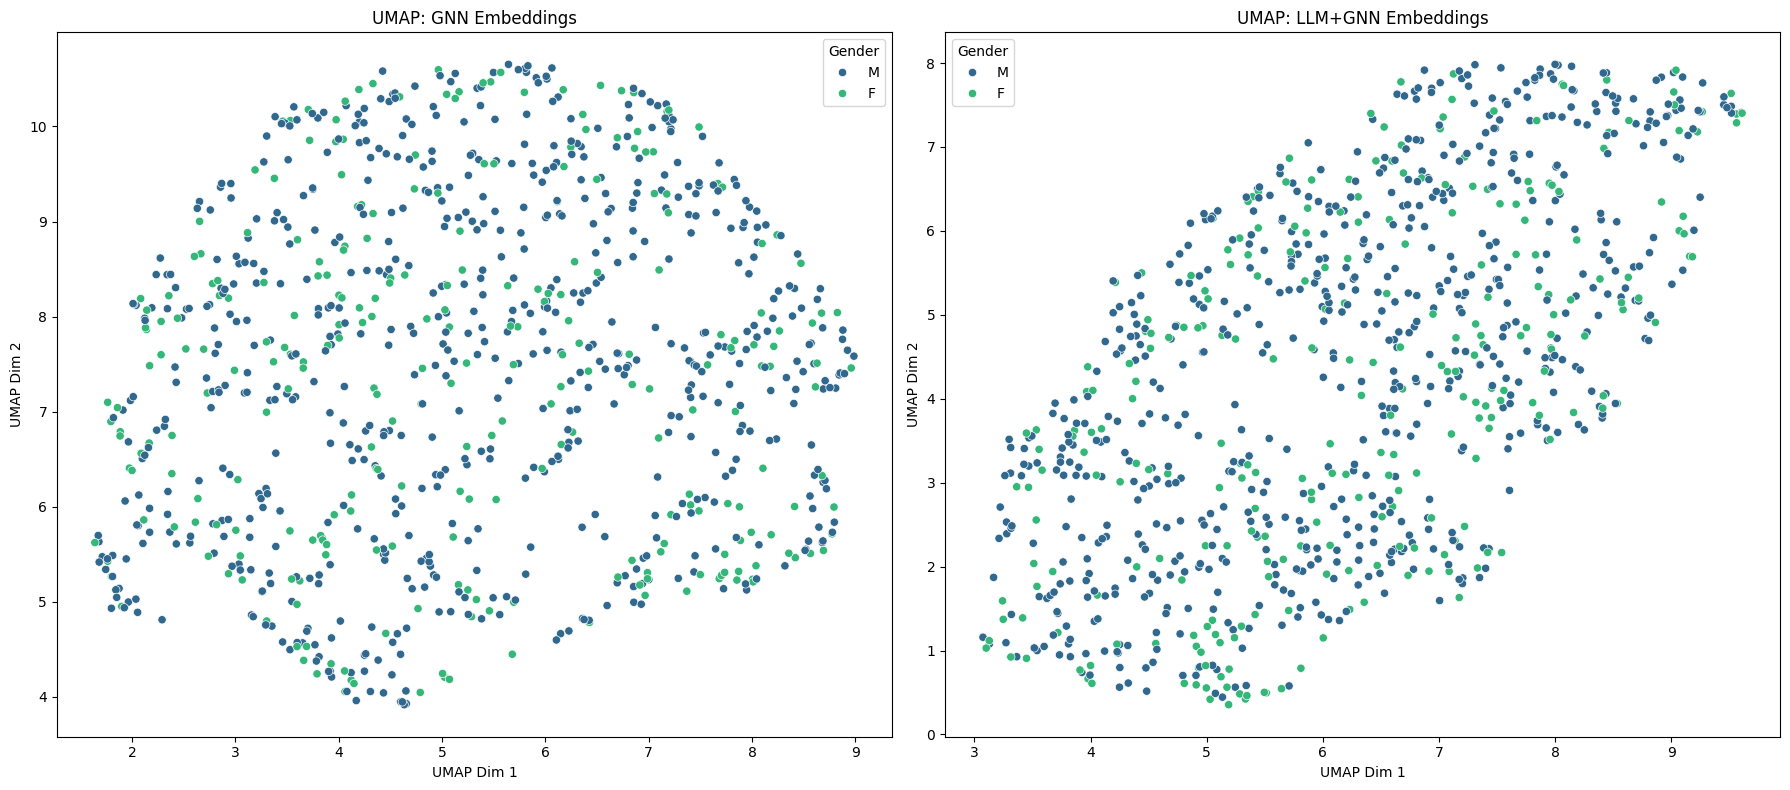

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# GNN
sns.scatterplot(
    ax=axes[0], x="umap_gnn_x", y="umap_gnn_y", hue="gender", data=users, palette="viridis"
)
axes[0].set_title("UMAP: GNN Embeddings")
axes[0].set_xlabel("UMAP Dim 1")
axes[0].set_ylabel("UMAP Dim 2")
axes[0].legend(title="Gender")

# GNN+LLM
sns.scatterplot(
    ax=axes[1], x="umap_llm_x", y="umap_llm_y", hue="gender", data=users, palette="viridis"
)
axes[1].set_title("UMAP: LLM+GNN Embeddings")
axes[1].set_xlabel("UMAP Dim 1")
axes[1].set_ylabel("UMAP Dim 2")
axes[1].legend(title="Gender")

plt.tight_layout()
plt.show()


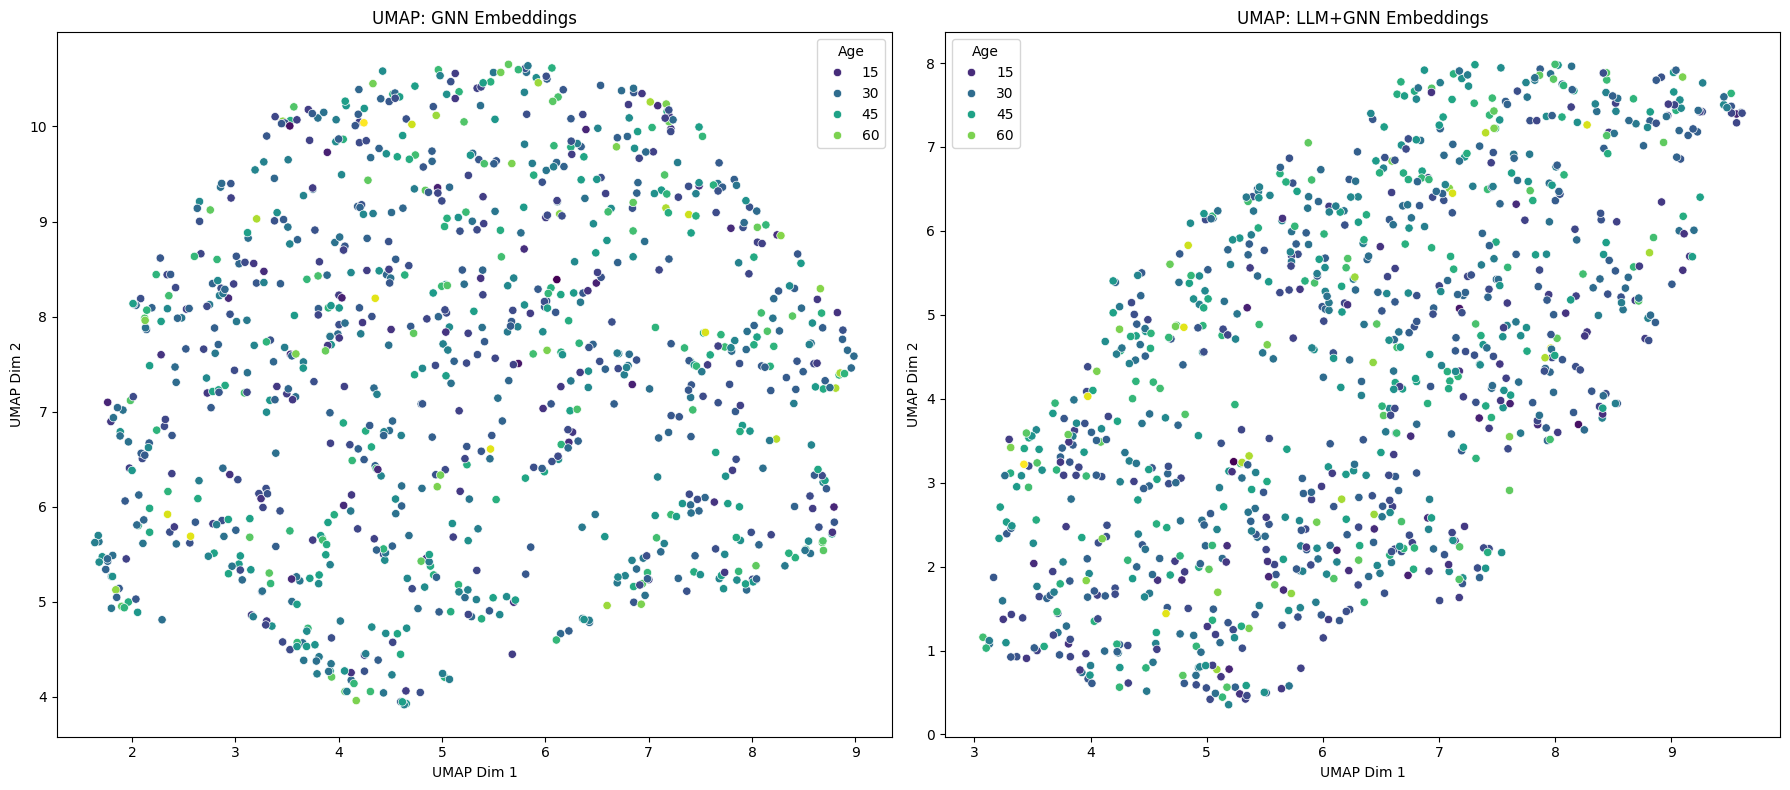

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# GNN
sns.scatterplot(
    ax=axes[0], x="umap_gnn_x", y="umap_gnn_y", hue="age", data=users, palette="viridis"
)
axes[0].set_title("UMAP: GNN Embeddings")
axes[0].set_xlabel("UMAP Dim 1")
axes[0].set_ylabel("UMAP Dim 2")
axes[0].legend(title="Age")

# GNN+LLM
sns.scatterplot(
    ax=axes[1], x="umap_llm_x", y="umap_llm_y", hue="age", data=users, palette="viridis"
)
axes[1].set_title("UMAP: LLM+GNN Embeddings")
axes[1].set_xlabel("UMAP Dim 1")
axes[1].set_ylabel("UMAP Dim 2")
axes[1].legend(title="Age")

plt.tight_layout()
plt.show()

# Same with PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_gnn = pca.fit_transform(gnn_embedding)
pca_llm = pca.fit_transform(llm_embedding)

In [ ]:
users["pca_gnn_x"] = pca_gnn[:, 0]
users["pca_gnn_y"] = pca_gnn[:, 1]
users["pca_llm_x"] = pca_llm[:, 0]
users["pca_llm_y"] = pca_llm[:, 1]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# GNN
sns.scatterplot(
    ax=axes[0], x="pca_gnn_x", y="pca_gnn_y", hue="gender", data=users, palette="viridis", alpha=0.8
)
axes[0].set_title("UMAP: GNN Embeddings")
axes[0].set_xlabel("UMAP Dim 1")
axes[0].set_ylabel("UMAP Dim 2")
axes[0].legend(title="Gender")

# GNN+LLM
sns.scatterplot(
    ax=axes[1], x="pca_llm_x", y="pca_llm_y", hue="gender", data=users, palette="viridis", alpha=0.8
)
axes[1].set_title("UMAP: LLM+GNN Embeddings")
axes[1].set_xlabel("UMAP Dim 1")
axes[1].set_ylabel("UMAP Dim 2")
axes[1].legend(title="Gender")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# GNN
sns.scatterplot(
    ax=axes[0], x="pca_gnn_x", y="pca_gnn_y", hue="age", data=users, palette="viridis", alpha=0.8
)
axes[0].set_title("UMAP: GNN Embeddings")
axes[0].set_xlabel("UMAP Dim 1")
axes[0].set_ylabel("UMAP Dim 2")
axes[0].legend(title="Gender")

# GNN+LLM
sns.scatterplot(
    ax=axes[1], x="pca_llm_x", y="pca_llm_y", hue="age", data=users, palette="viridis", alpha=0.8
)
axes[1].set_title("UMAP: LLM+GNN Embeddings")
axes[1].set_xlabel("UMAP Dim 1")
axes[1].set_ylabel("UMAP Dim 2")
axes[1].legend(title="Gender")

plt.tight_layout()
plt.show()

# Compare Embeddings

In [ ]:
pca = PCA(n_components=16)  # Reduce to 128 dimensions
reduced_gnn_embedding = pca.fit_transform(gnn_embedding)
reduced_llm_embedding = pca.fit_transform(llm_embedding)

In [ ]:
user_cosine_similarities = [
    cosine_similarity(gnn_embedding[i].reshape(1, -1), llm_embedding[i].reshape(1, -1))[0][0]
    for i in range(len(gnn_embedding))
]

print(f"Avg cosine similarity between GNN and LLM embeddings: {np.mean(user_cosine_similarities)}")
print(f"Min similarity: {np.min(user_cosine_similarities)}, Max similarity: {np.max(user_cosine_similarities)}")

plt.figure(figsize=(8, 6))
plt.hist(user_cosine_similarities, bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Cosine Similarities Between GNN and LLM Embeddings')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

user_cosine_similarities_pca = [
    cosine_similarity(reduced_gnn_embedding[i].reshape(1, -1), reduced_llm_embedding[i].reshape(1, -1))[0][0]
    for i in range(len(gnn_embedding))
]

# Analyze similarities
print(f"Avg cosine similarity between GNN and LLM embeddings: {np.mean(user_cosine_similarities_pca)}")
print(f"Min similarity: {np.min(user_cosine_similarities_pca)}, Max similarity: {np.max(user_cosine_similarities_pca)}")

plt.figure(figsize=(8, 6))
plt.hist(user_cosine_similarities_pca, bins=30, edgecolor='black', alpha=0.7)
plt.title('PCA: Distribution of Cosine Similarities Between GNN and LLM Embeddings')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
y.shape

# Node Classifc Embeds

In [15]:
node_embedding = torch.load('node_embeds.pt')

/var/folders/jd/4hblgkwx24zg166lcr8sj2200000gn/T/ipykernel_60176/1661187940.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  node_embedding = torch.load('node_embeds.pt')

In [16]:
umap_node = UMAP(n_components=2, random_state=42).fit_transform(node_embedding)

# Add to metadata for visualization
users["umap_node_x"] = umap_node[:, 0]
users["umap_node_y"] = umap_node[:, 1]

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


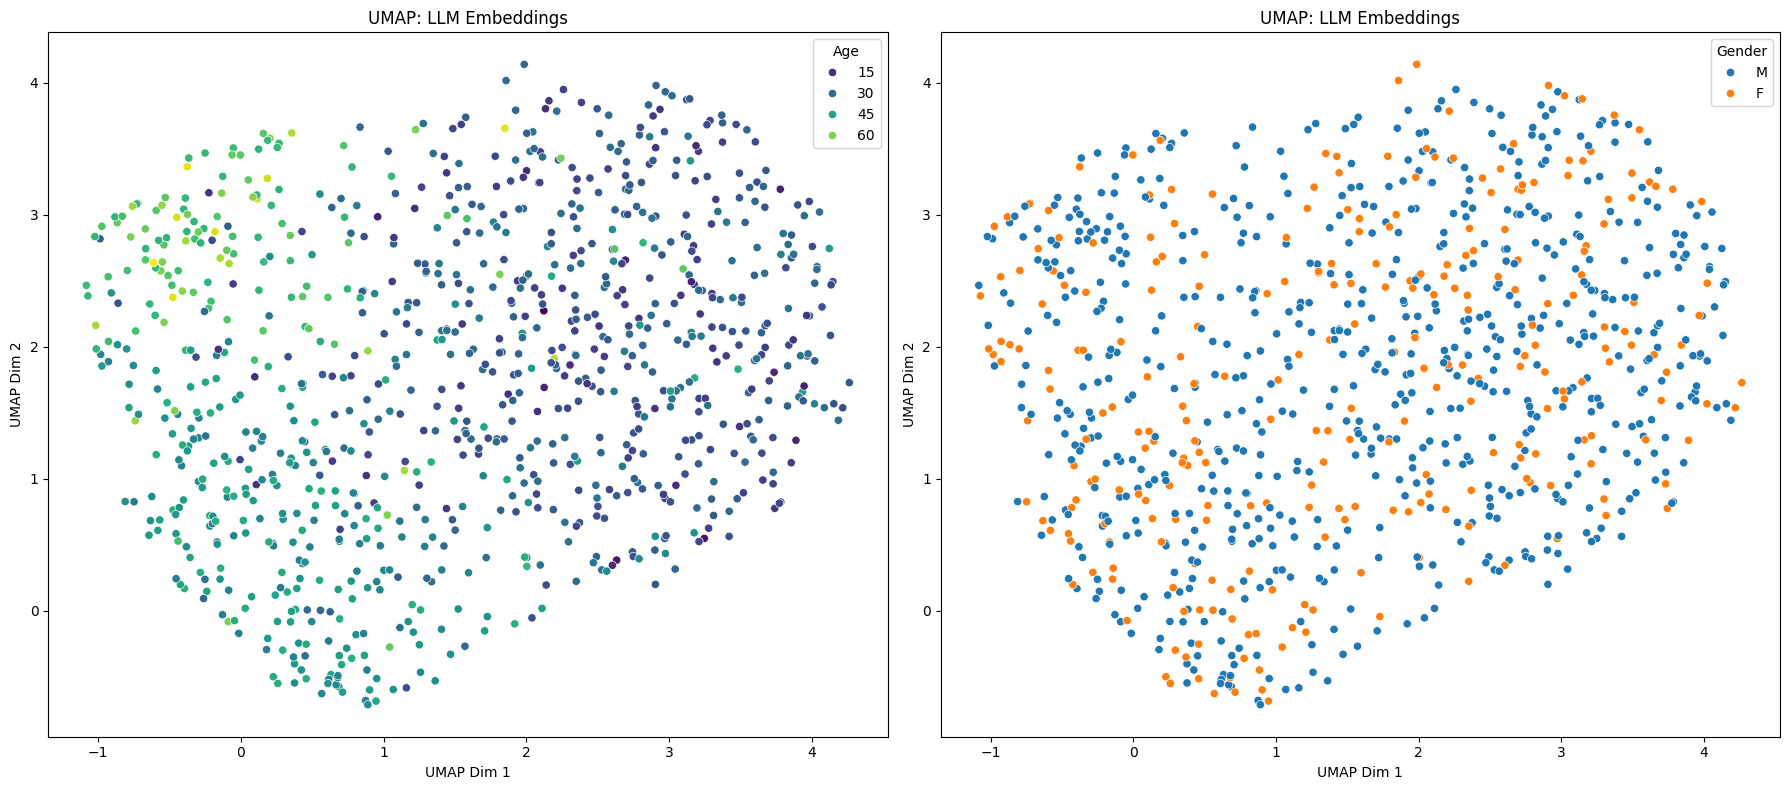

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# GNN
sns.scatterplot(
    ax=axes[0], x="umap_node_x", y="umap_node_y", hue="age", data=users, palette="viridis"
)
axes[0].set_title("UMAP: LLM Embeddings")
axes[0].set_xlabel("UMAP Dim 1")
axes[0].set_ylabel("UMAP Dim 2")
axes[0].legend(title="Age")

# GNN+LLM
sns.scatterplot(
    ax=axes[1], x="umap_node_x", y="umap_node_y", hue="gender", data=users
)
axes[1].set_title("UMAP: LLM Embeddings")
axes[1].set_xlabel("UMAP Dim 1")
axes[1].set_ylabel("UMAP Dim 2")
axes[1].legend(title="Gender")

plt.tight_layout()
plt.show()

# Movie Popularity

In [18]:
movies = pd.read_csv('/Users/sebastian/University/Master/third term/sem-proj/kg-token/data/ml-100k/u.item', header=None, sep='|', encoding='latin1')
movies.columns = ['movie_id', 'movie_title', 'release_date', 'video_release_date', 'IMDb_URL', 'unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy', 'Crime',
                       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery',
                       'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

ratings_train = pd.read_csv('/Users/sebastian/University/Master/third term/sem-proj/kg-token/data/ml-100k/ua.base', header=None, sep='\t', encoding='latin1')
ratings_train.columns = ['user_id', 'movie_id', 'rating', 'timestamp']

In [19]:
movies = movies[['movie_id', 'movie_title']]

In [20]:
movies

,movie_id,movie_title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)
...,...,...
1677,1678,Mat' i syn (1997)
1678,1679,B. Monkey (1998)
1679,1680,Sliding Doors (1998)
1680,1681,You So Crazy (1994)


In [21]:
ratings_train

,user_id,movie_id,rating,timestamp
0,1,1,5,874965758
1,1,2,3,876893171
2,1,3,4,878542960
3,1,4,3,876893119
4,1,5,3,889751712
...,...,...,...,...
90565,943,1047,2,875502146
90566,943,1074,4,888640250
90567,943,1188,3,888640250
90568,943,1228,3,888640275


In [22]:
movie_counts = ratings_train['movie_id'].value_counts().reset_index()
movie_counts.columns = ['movie_id', 'rating_count']

# Merging the counts back into the movies dataframe
movies_with_counts = movies.merge(movie_counts, on='movie_id', how='left')

In [23]:
movies_with_counts

,movie_id,movie_title,rating_count
0,1,Toy Story (1995),392.0
1,2,GoldenEye (1995),121.0
2,3,Four Rooms (1995),85.0
3,4,Get Shorty (1995),198.0
4,5,Copycat (1995),79.0
...,...,...,...
1677,1678,Mat' i syn (1997),1.0
1678,1679,B. Monkey (1998),1.0
1679,1680,Sliding Doors (1998),1.0
1680,1681,You So Crazy (1994),1.0


In [24]:
movies_with_counts['bins'] = pd.cut(movies_with_counts['rating_count'], bins=10, labels=False)

In [25]:
movies_with_counts.loc[movies_with_counts['rating_count'] == 1, 'bins'] = 10

In [26]:
movies_with_counts

,movie_id,movie_title,rating_count,bins
0,1,Toy Story (1995),392.0,7.0
1,2,GoldenEye (1995),121.0,2.0
2,3,Four Rooms (1995),85.0,1.0
3,4,Get Shorty (1995),198.0,3.0
4,5,Copycat (1995),79.0,1.0
...,...,...,...,...
1677,1678,Mat' i syn (1997),1.0,10.0
1678,1679,B. Monkey (1998),1.0,10.0
1679,1680,Sliding Doors (1998),1.0,10.0
1680,1681,You So Crazy (1994),1.0,10.0


In [27]:
movie_embedding = torch.load('movie_embeds.pt')

/var/folders/jd/4hblgkwx24zg166lcr8sj2200000gn/T/ipykernel_60176/1884615590.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  movie_embedding = torch.load('movie_embeds.pt

In [28]:
movie_embedding.shape

torch.Size([1682, 512])

In [29]:
umap_movie = UMAP(n_components=2, random_state=42).fit_transform(movie_embedding)

# Add to metadata for visualization
movies_with_counts["umap_x"] = umap_movie[:, 0]
movies_with_counts["umap_y"] = umap_movie[:, 1]

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


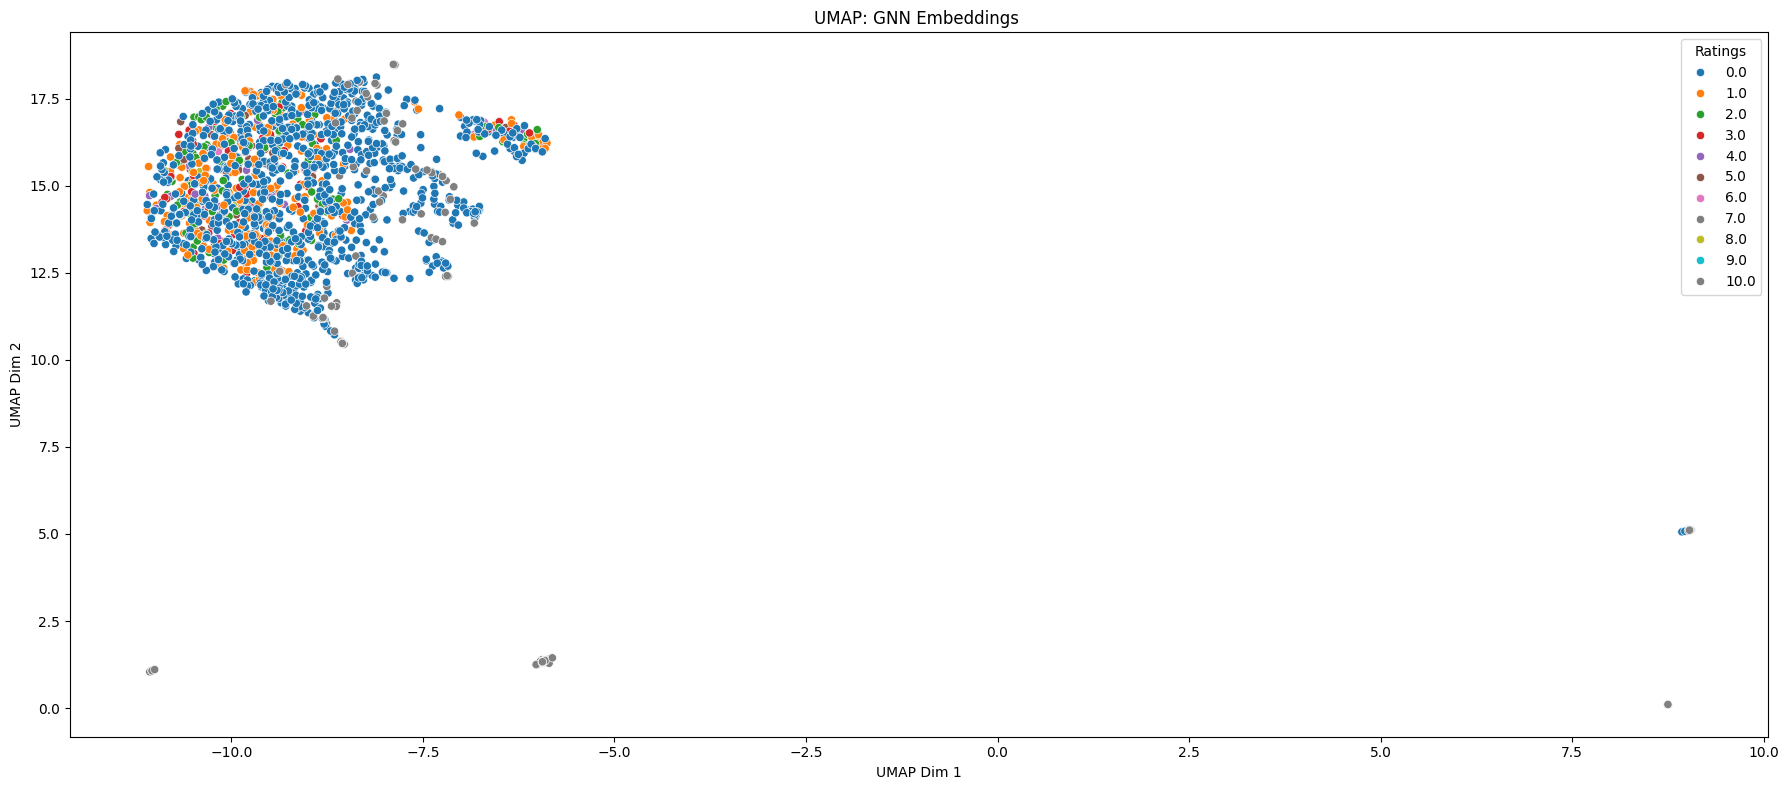

In [30]:
custom_palette = sns.color_palette("tab10", 10) + [(0.5, 0.5, 0.5)]  

fig, axes = plt.subplots(1, 1, figsize=(18, 8))

sns.scatterplot(
    ax=axes,
    x="umap_x",
    y="umap_y",
    hue="bins",
    data=movies_with_counts,
    palette=custom_palette
)

axes.set_title("UMAP: GNN Embeddings ")
axes.set_xlabel("UMAP Dim 1")
axes.set_ylabel("UMAP Dim 2")
axes.legend(title="Ratings")

plt.tight_layout()
plt.show()

In [ ]:
# Would Toy Story 5 be successfull? 

# Would these users aged 25-49 [user_embeds] like a new action movie and why?
# -> Im Netflix and want to know where to allocate budget
# Why? Is benefit of LLM

# Would the next James Bond be popular based on these prequels [james_bond_embeddings]. Why?